# E-Commerce Delivery Delay Prediction

## Project Overview

This project analyses Brazilian e-commerce order data to understand delivery performance and identify factors associated with delivery delays.

The project follows an end-to-end data analytics and machine-learning workflow, from data preparation and exploratory analysis through to predictive modelling and business recommendations.

## Business Problem

Late deliveries can negatively affect customer satisfaction and increase operational costs. The objective of this project is to analyse historical order data and develop a classification model that can identify orders with a higher likelihood of being delivered late.

Rather than focusing only on overall prediction accuracy, the project places particular emphasis on identifying the minority **Late** class using precision, recall and F1-score.

## Project Objectives

- Inspect and clean the raw e-commerce datasets.
- Explore delivery patterns using exploratory data analysis.
- Engineer features that may help explain delivery performance.
- Identify differences between late and on-time orders.
- Develop and compare multiple classification models.
- Evaluate models using accuracy, precision, recall and F1-score.
- Address the imbalance between late and on-time deliveries.
- Optimise the classification threshold to improve detection of late deliveries.
- Translate analytical findings into practical business recommendations.

## Tools & Technologies

- **Python**
- **Pandas** — data manipulation and analysis
- **NumPy** — numerical operations
- **Matplotlib** — data visualisation
- **Scikit-learn** — machine learning and model evaluation
- **Jupyter Notebook** — analysis and documentation

## Dataset

The analysis uses Brazilian e-commerce order data containing information about orders, customers, products, payments, reviews and sellers.

The datasets were combined where appropriate to create an analytical dataset for delivery-performance analysis.

## Target Variable

The main prediction target is:

**`delivery_status`**

with two classes:

- **On Time**
- **Late**

Because late deliveries represent a substantially smaller proportion of the dataset, model evaluation considers the performance of the **Late** class rather than relying on accuracy alone.

## Final Modelling Approach

Several machine-learning approaches were tested and compared.

The final selected configuration uses a **Random Forest classifier** with customer geographic information and a classification threshold of **0.30**.

The threshold was adjusted from the default 0.50 to improve the model's ability to identify potentially late deliveries.

### Final Model Performance

| Metric | Result |
|---|---:|
| Accuracy | 87.0% |
| Late Precision | 22% |
| Late Recall | 40% |
| Late F1-score | 28% |

The threshold adjustment increased recall for the Late class from **18% to 40%**, improving the model's ability to identify potentially delayed orders.

## Project Structure

The analysis follows this workflow:

**Data Inspection → Data Cleaning → EDA → Feature Engineering → Machine Learning → Model Evaluation → Threshold Optimisation → Business Recommendations**

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)
from sklearn.ensemble import RandomForestClassifier

In [3]:
orders = pd.read_csv("../data/orders_clean.csv")
order_items = pd.read_csv("../data/order_items_clean.csv")

print("Orders:", orders.shape)
print("Order items:", order_items.shape)

Orders: (99441, 10)
Order items: (112650, 7)


In [4]:
orders["order_delivered_customer_date"] = pd.to_datetime(
    orders["order_delivered_customer_date"]
)

orders["order_estimated_delivery_date"] = pd.to_datetime(
    orders["order_estimated_delivery_date"]
)

In [5]:
orders["delivery_delay_days"] = (
    orders["order_delivered_customer_date"]
    - orders["order_estimated_delivery_date"]
).dt.days

In [6]:
orders["delivery_status"] = orders["delivery_delay_days"].apply(
    lambda x: "Late" if x > 0 else "On Time"
)

In [7]:
print(orders["delivery_status"].value_counts())

delivery_status
On Time    92906
Late        6535
Name: count, dtype: int64


In [8]:
y = orders["delivery_status"]

In [9]:
X = orders[
    [
        "order_purchase_timestamp",
        "customer_id"
    ]
]

In [11]:
orders["order_purchase_timestamp"] = pd.to_datetime(
    orders["order_purchase_timestamp"]
)

In [12]:
orders["purchase_year"] = orders["order_purchase_timestamp"].dt.year
orders["purchase_month"] = orders["order_purchase_timestamp"].dt.month
orders["purchase_dayofweek"] = orders["order_purchase_timestamp"].dt.dayofweek
orders["purchase_hour"] = orders["order_purchase_timestamp"].dt.hour

In [13]:
X = orders[
    [
        "purchase_year",
        "purchase_month",
        "purchase_dayofweek",
        "purchase_hour"
    ]
]

y = orders["delivery_status"]

In [14]:
print("Features:")
print(X.head())

print("\nTarget:")
print(y.head())

Features:
   purchase_year  purchase_month  purchase_dayofweek  purchase_hour
0           2017              10                   0             10
1           2018               7                   1             20
2           2018               8                   2              8
3           2017              11                   5             19
4           2018               2                   1             21

Target:
0    On Time
1    On Time
2    On Time
3    On Time
4    On Time
Name: delivery_status, dtype: str


In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [16]:
print("Training features:", X_train.shape)
print("Testing features:", X_test.shape)

print("Training target:", y_train.shape)
print("Testing target:", y_test.shape)

Training features: (79552, 4)
Testing features: (19889, 4)
Training target: (79552,)
Testing target: (19889,)


In [17]:
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight="balanced"
)

model.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"class_weight class_weight: {""balanced"", ""balanced_subsample""}, dict or list of dicts, default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``The ""balanced_subsample"" mode is the same as ""balanced"" except thatweights are computed based on the bootstrap sample for every treegrown.For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.",'balanced'
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.

In [18]:
y_pred = model.predict(X_test)

In [19]:
print(y_pred[:20])

['Late' 'On Time' 'On Time' 'On Time' 'On Time' 'On Time' 'On Time' 'Late'
 'Late' 'Late' 'Late' 'Late' 'Late' 'Late' 'Late' 'On Time' 'On Time'
 'On Time' 'Late' 'Late']


In [20]:
from sklearn.metrics import accuracy_score, classification_report

accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.2%}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 62.21%

Classification Report:
              precision    recall  f1-score   support

        Late       0.10      0.61      0.17      1307
     On Time       0.96      0.62      0.75     18582

    accuracy                           0.62     19889
   macro avg       0.53      0.62      0.46     19889
weighted avg       0.90      0.62      0.72     19889



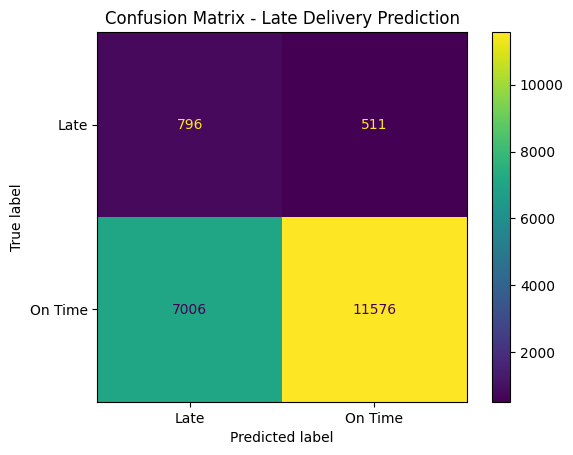

In [21]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred
)

plt.title("Confusion Matrix - Late Delivery Prediction")
plt.show()

In [22]:
items_per_order = (
    order_items
    .groupby("order_id")
    .size()
    .reset_index(name="item_count")
)

print(items_per_order.head())

                           order_id  item_count
0  00010242fe8c5a6d1ba2dd792cb16214           1
1  00018f77f2f0320c557190d7a144bdd3           1
2  000229ec398224ef6ca0657da4fc703e           1
3  00024acbcdf0a6daa1e931b038114c75           1
4  00042b26cf59d7ce69dfabb4e55b4fd9           1


In [23]:
order_value = (
    order_items
    .groupby("order_id")["price"]
    .sum()
    .reset_index(name="order_value")
)

print(order_value.head())

                           order_id  order_value
0  00010242fe8c5a6d1ba2dd792cb16214        58.90
1  00018f77f2f0320c557190d7a144bdd3       239.90
2  000229ec398224ef6ca0657da4fc703e       199.00
3  00024acbcdf0a6daa1e931b038114c75        12.99
4  00042b26cf59d7ce69dfabb4e55b4fd9       199.90


In [24]:
freight_per_order = (
    order_items
    .groupby("order_id")["freight_value"]
    .sum()
    .reset_index(name="freight_value")
)

print(freight_per_order.head())

                           order_id  freight_value
0  00010242fe8c5a6d1ba2dd792cb16214          13.29
1  00018f77f2f0320c557190d7a144bdd3          19.93
2  000229ec398224ef6ca0657da4fc703e          17.87
3  00024acbcdf0a6daa1e931b038114c75          12.79
4  00042b26cf59d7ce69dfabb4e55b4fd9          18.14


In [25]:
ml_data = orders.merge(
    items_per_order,
    on="order_id",
    how="left"
)

ml_data = ml_data.merge(
    order_value,
    on="order_id",
    how="left"
)

ml_data = ml_data.merge(
    freight_per_order,
    on="order_id",
    how="left"
)

In [26]:
print(ml_data[
    [
        "order_id",
        "item_count",
        "order_value",
        "freight_value"
    ]
].head())

                           order_id  item_count  order_value  freight_value
0  e481f51cbdc54678b7cc49136f2d6af7         1.0        29.99           8.72
1  53cdb2fc8bc7dce0b6741e2150273451         1.0       118.70          22.76
2  47770eb9100c2d0c44946d9cf07ec65d         1.0       159.90          19.22
3  949d5b44dbf5de918fe9c16f97b45f8a         1.0        45.00          27.20
4  ad21c59c0840e6cb83a9ceb5573f8159         1.0        19.90           8.72


In [27]:
X2 = ml_data[
    [
        "purchase_year",
        "purchase_month",
        "purchase_dayofweek",
        "purchase_hour",
        "item_count",
        "order_value",
        "freight_value"
    ]
]

y2 = ml_data["delivery_status"]

In [28]:
print(X2.head())
print("\nFeatures:", X2.columns.tolist())

   purchase_year  purchase_month  purchase_dayofweek  purchase_hour  \
0           2017              10                   0             10   
1           2018               7                   1             20   
2           2018               8                   2              8   
3           2017              11                   5             19   
4           2018               2                   1             21   

   item_count  order_value  freight_value  
0         1.0        29.99           8.72  
1         1.0       118.70          22.76  
2         1.0       159.90          19.22  
3         1.0        45.00          27.20  
4         1.0        19.90           8.72  

Features: ['purchase_year', 'purchase_month', 'purchase_dayofweek', 'purchase_hour', 'item_count', 'order_value', 'freight_value']


In [29]:
X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2,
    y2,
    test_size=0.20,
    random_state=42,
    stratify=y2
)

In [30]:
model2 = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)

model2.fit(X2_train, y2_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"class_weight class_weight: {""balanced"", ""balanced_subsample""}, dict or list of dicts, default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``The ""balanced_subsample"" mode is the same as ""balanced"" except thatweights are computed based on the bootstrap sample for every treegrown.For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.",'balanced'
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_fe

In [31]:
y2_pred = model2.predict(X2_test)

In [32]:
accuracy2 = accuracy_score(y2_test, y2_pred)

print(f"Model 2 Accuracy: {accuracy2:.2%}")

print("\nModel 2 Classification Report:")
print(classification_report(y2_test, y2_pred))

Model 2 Accuracy: 91.09%

Model 2 Classification Report:
              precision    recall  f1-score   support

        Late       0.18      0.10      0.13      1307
     On Time       0.94      0.97      0.95     18582

    accuracy                           0.91     19889
   macro avg       0.56      0.54      0.54     19889
weighted avg       0.89      0.91      0.90     19889



In [33]:
feature_importance = pd.Series(
    model2.feature_importances_,
    index=X2.columns
).sort_values(ascending=False)

print(feature_importance)

freight_value         0.289268
order_value           0.288503
purchase_hour         0.163922
purchase_month        0.143458
purchase_dayofweek    0.080379
purchase_year         0.019915
item_count            0.014555
dtype: float64


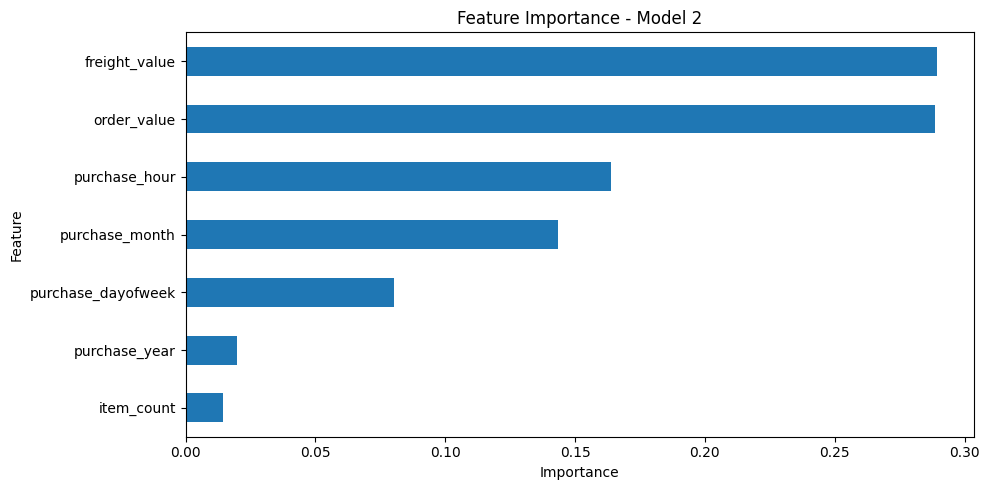

In [34]:
plt.figure(figsize=(10, 5))

feature_importance.sort_values().plot(
    kind="barh"
)

plt.title("Feature Importance - Model 2")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

In [35]:
print(y2.value_counts())

print("\nClass proportions:")
print(y2.value_counts(normalize=True))

delivery_status
On Time    92906
Late        6535
Name: count, dtype: int64

Class proportions:
delivery_status
On Time    0.934283
Late       0.065717
Name: proportion, dtype: float64


In [36]:
model3 = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced_subsample",
    n_jobs=-1
)

model3.fit(X2_train, y2_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"class_weight class_weight: {""balanced"", ""balanced_subsample""}, dict or list of dicts, default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``The ""balanced_subsample"" mode is the same as ""balanced"" except thatweights are computed based on the bootstrap sample for every treegrown.For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.",'balanced_subsample'
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consid

In [37]:
y3_pred = model3.predict(X2_test)

In [38]:
accuracy3 = accuracy_score(y2_test, y3_pred)

print(f"Model 3 Accuracy: {accuracy3:.2%}")

print("\nModel 3 Classification Report:")
print(classification_report(y2_test, y3_pred))

Model 3 Accuracy: 93.18%

Model 3 Classification Report:
              precision    recall  f1-score   support

        Late       0.24      0.02      0.03      1307
     On Time       0.94      1.00      0.96     18582

    accuracy                           0.93     19889
   macro avg       0.59      0.51      0.50     19889
weighted avg       0.89      0.93      0.90     19889



In [39]:
ml_data["order_purchase_timestamp"] = pd.to_datetime(
    ml_data["order_purchase_timestamp"]
)

ml_data["order_estimated_delivery_date"] = pd.to_datetime(
    ml_data["order_estimated_delivery_date"]
)

ml_data["estimated_delivery_days"] = (
    ml_data["order_estimated_delivery_date"]
    - ml_data["order_purchase_timestamp"]
).dt.days

In [40]:
print(
    ml_data["estimated_delivery_days"].describe()
)

count    99441.000000
mean        23.403958
std          8.829562
min          1.000000
25%         18.000000
50%         23.000000
75%         28.000000
max        155.000000
Name: estimated_delivery_days, dtype: float64


In [41]:
X4 = ml_data[
    [
        "purchase_year",
        "purchase_month",
        "purchase_dayofweek",
        "purchase_hour",
        "item_count",
        "order_value",
        "freight_value",
        "estimated_delivery_days"
    ]
]

y4 = ml_data["delivery_status"]

In [42]:
X4_train, X4_test, y4_train, y4_test = train_test_split(
    X4,
    y4,
    test_size=0.20,
    random_state=42,
    stratify=y4
)

In [43]:
model4 = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)

model4.fit(X4_train, y4_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"class_weight class_weight: {""balanced"", ""balanced_subsample""}, dict or list of dicts, default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``The ""balanced_subsample"" mode is the same as ""balanced"" except thatweights are computed based on the bootstrap sample for every treegrown.For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.",'balanced'
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_fe

In [44]:
y4_pred = model4.predict(X4_test)

In [45]:
accuracy4 = accuracy_score(y4_test, y4_pred)

print(f"Model 4 Accuracy: {accuracy4:.2%}")

print("\nModel 4 Classification Report:")
print(classification_report(y4_test, y4_pred))

Model 4 Accuracy: 91.87%

Model 4 Classification Report:
              precision    recall  f1-score   support

        Late       0.25      0.12      0.16      1307
     On Time       0.94      0.98      0.96     18582

    accuracy                           0.92     19889
   macro avg       0.59      0.55      0.56     19889
weighted avg       0.89      0.92      0.90     19889



In [46]:
late_summary = ml_data.groupby("delivery_status")[
    [
        "estimated_delivery_days",
        "freight_value",
        "order_value",
        "item_count"
    ]
].mean()

print(late_summary)

                 estimated_delivery_days  freight_value  order_value  \
delivery_status                                                        
Late                           22.289518      25.245890   150.872889   
On Time                        23.482348      22.651742   136.823538   

                 item_count  
delivery_status              
Late               1.111706  
On Time            1.143860  


In [48]:
customers = pd.read_csv("../data/customers_clean.csv")

In [49]:
print(customers.columns.tolist())

['customer_id', 'customer_unique_id', 'customer_zip_code_prefix', 'customer_city', 'customer_state']


In [50]:
ml_data = ml_data.merge(
    customers[["customer_id", "customer_state"]],
    on="customer_id",
    how="left"
)

In [51]:
print(ml_data[["customer_id", "customer_state"]].head())
print("\nNumber of states:", ml_data["customer_state"].nunique())

                        customer_id customer_state
0  9ef432eb6251297304e76186b10a928d             SP
1  b0830fb4747a6c6d20dea0b8c802d7ef             BA
2  41ce2a54c0b03bf3443c3d931a367089             GO
3  f88197465ea7920adcdbec7375364d82             RN
4  8ab97904e6daea8866dbdbc4fb7aad2c             SP

Number of states: 27


In [52]:
X5 = ml_data[
    [
        "purchase_year",
        "purchase_month",
        "purchase_dayofweek",
        "purchase_hour",
        "item_count",
        "order_value",
        "freight_value",
        "estimated_delivery_days",
        "customer_state"
    ]
]

y5 = ml_data["delivery_status"]

In [53]:
categorical_features = ["customer_state"]

numeric_features = [
    "purchase_year",
    "purchase_month",
    "purchase_dayofweek",
    "purchase_hour",
    "item_count",
    "order_value",
    "freight_value",
    "estimated_delivery_days"
]

In [54]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        )
    ],
    remainder="passthrough"
)

In [55]:
model5 = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            RandomForestClassifier(
                n_estimators=200,
                random_state=42,
                class_weight="balanced",
                n_jobs=-1
            )
        )
    ]
)

In [56]:
X5_train, X5_test, y5_train, y5_test = train_test_split(
    X5,
    y5,
    test_size=0.20,
    random_state=42,
    stratify=y5
)

In [58]:
print(X5["customer_state"].isna().sum())

0


In [59]:
print(X5.isna().sum())

purchase_year                0
purchase_month               0
purchase_dayofweek           0
purchase_hour                0
item_count                 775
order_value                775
freight_value              775
estimated_delivery_days      0
customer_state               0
dtype: int64


In [60]:
X5[
    ["item_count", "order_value", "freight_value"]
] = X5[
    ["item_count", "order_value", "freight_value"]
].fillna(0)

In [61]:
print(X5.isna().sum())

purchase_year              0
purchase_month             0
purchase_dayofweek         0
purchase_hour              0
item_count                 0
order_value                0
freight_value              0
estimated_delivery_days    0
customer_state             0
dtype: int64


In [63]:
X5_train, X5_test, y5_train, y5_test = train_test_split(
    X5,
    y5,
    test_size=0.20,
    random_state=42,
    stratify=y5
)

In [64]:
model5.fit(X5_train, y5_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[object](2,)","['Late','On Time']"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](9,)","['purchase_year','purchase_month','purchase_dayofweek',...,'freight_value', 'estimated_delivery_days','customer_state']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,9
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('categorical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of 

In [65]:
y5_pred = model5.predict(X5_test)

In [66]:
accuracy5 = accuracy_score(y5_test, y5_pred)

print(f"Model 5 Accuracy: {accuracy5:.2%}")

print("\nModel 5 Classification Report:")
print(classification_report(y5_test, y5_pred))

Model 5 Accuracy: 92.14%

Model 5 Classification Report:
              precision    recall  f1-score   support

        Late       0.32      0.18      0.23      1307
     On Time       0.94      0.97      0.96     18582

    accuracy                           0.92     19889
   macro avg       0.63      0.58      0.59     19889
weighted avg       0.90      0.92      0.91     19889



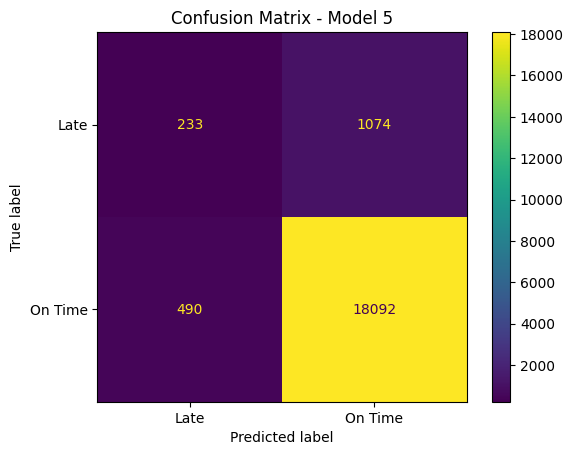

In [67]:
ConfusionMatrixDisplay.from_predictions(
    y5_test,
    y5_pred
)

plt.title("Confusion Matrix - Model 5")
plt.show()

In [72]:
from sklearn.preprocessing import StandardScaler

In [73]:
from sklearn.linear_model import LogisticRegression

In [75]:
preprocessor_lr = ColumnTransformer(
    transformers=[
        (
            "numeric",
            StandardScaler(),
            numeric_features
        ),
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        )
    ]
)

In [76]:
model6 = Pipeline(
    steps=[
        ("preprocessor", preprocessor_lr),
        (
            "classifier",
            LogisticRegression(
                max_iter=2000,
                class_weight="balanced"
            )
        )
    ]
)

In [77]:
model6.fit(X5_train, y5_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[object](2,)","['Late','On Time']"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](9,)","['purchase_year','purchase_month','purchase_dayofweek',...,'freight_value', 'estimated_delivery_days','customer_state']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,9
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric', ...), ('categorical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dro

In [78]:
y6_pred = model6.predict(X5_test)

In [79]:
accuracy6 = accuracy_score(y5_test, y6_pred)

print(f"Model 6 Accuracy: {accuracy6:.2%}")

print("\nModel 6 Classification Report:")
print(classification_report(y5_test, y6_pred))

Model 6 Accuracy: 65.43%

Model 6 Classification Report:
              precision    recall  f1-score   support

        Late       0.11      0.60      0.19      1307
     On Time       0.96      0.66      0.78     18582

    accuracy                           0.65     19889
   macro avg       0.53      0.63      0.48     19889
weighted avg       0.90      0.65      0.74     19889



In [82]:
y5_proba = model5.predict_proba(X5_test)[:, 0]

In [83]:
print(y5_proba[:10])

[0.17  0.245 0.01  0.005 0.035 0.11  0.045 0.24  0.    0.03 ]


In [85]:
import numpy as np
threshold = 0.30

y5_threshold_pred = np.where(
    y5_proba >= threshold,
    "Late",
    "On Time"
)

In [86]:
print(classification_report(
    y5_test,
    y5_threshold_pred
))

              precision    recall  f1-score   support

        Late       0.22      0.40      0.28      1307
     On Time       0.96      0.90      0.93     18582

    accuracy                           0.87     19889
   macro avg       0.59      0.65      0.60     19889
weighted avg       0.91      0.87      0.88     19889



In [87]:
for threshold in [0.20, 0.25, 0.30, 0.35, 0.40, 0.45, 0.50]:
    
    predictions = np.where(
        y5_proba >= threshold,
        "Late",
        "On Time"
    )
    
    report = classification_report(
        y5_test,
        predictions,
        output_dict=True
    )
    
    print(
        f"Threshold: {threshold:.2f} | "
        f"Late Precision: {report['Late']['precision']:.2f} | "
        f"Late Recall: {report['Late']['recall']:.2f} | "
        f"Late F1: {report['Late']['f1-score']:.2f} | "
        f"Accuracy: {report['accuracy']:.2f}"
    )

Threshold: 0.20 | Late Precision: 0.17 | Late Recall: 0.56 | Late F1: 0.26 | Accuracy: 0.80
Threshold: 0.25 | Late Precision: 0.20 | Late Recall: 0.48 | Late F1: 0.28 | Accuracy: 0.84
Threshold: 0.30 | Late Precision: 0.22 | Late Recall: 0.40 | Late F1: 0.28 | Accuracy: 0.87
Threshold: 0.35 | Late Precision: 0.23 | Late Recall: 0.32 | Late F1: 0.27 | Accuracy: 0.88
Threshold: 0.40 | Late Precision: 0.25 | Late Recall: 0.26 | Late F1: 0.26 | Accuracy: 0.90
Threshold: 0.45 | Late Precision: 0.28 | Late Recall: 0.22 | Late F1: 0.24 | Accuracy: 0.91
Threshold: 0.50 | Late Precision: 0.32 | Late Recall: 0.18 | Late F1: 0.23 | Accuracy: 0.92


In [89]:
model_comparison = pd.DataFrame({
    "Model": [
        "Model 1 - Random Forest",
        "Model 2 - Random Forest + Order Features",
        "Model 3 - Balanced Random Forest",
        "Model 4 - + Estimated Delivery",
        "Model 5 - + Customer State",
        "Model 6 - Logistic Regression",
        "Model 5 - Threshold 0.30"
    ],
    "Accuracy": [
        0.6221,
        0.9109,
        0.9318,
        0.9187,
        0.9214,
        0.6543,
        0.8700
    ],
    "Late Precision": [
        0.10,
        0.18,
        0.24,
        0.25,
        0.32,
        0.11,
        0.22
    ],
    "Late Recall": [
        0.61,
        0.10,
        0.02,
        0.12,
        0.18,
        0.60,
        0.40
    ],
    "Late F1": [
        0.17,
        0.13,
        0.03,
        0.16,
        0.23,
        0.19,
        0.28
    ]
})

print(model_comparison)

                                      Model  Accuracy  Late Precision  \
0                   Model 1 - Random Forest    0.6221            0.10   
1  Model 2 - Random Forest + Order Features    0.9109            0.18   
2          Model 3 - Balanced Random Forest    0.9318            0.24   
3            Model 4 - + Estimated Delivery    0.9187            0.25   
4                Model 5 - + Customer State    0.9214            0.32   
5             Model 6 - Logistic Regression    0.6543            0.11   
6                  Model 5 - Threshold 0.30    0.8700            0.22   

   Late Recall  Late F1  
0         0.61     0.17  
1         0.10     0.13  
2         0.02     0.03  
3         0.12     0.16  
4         0.18     0.23  
5         0.60     0.19  
6         0.40     0.28  


In [91]:
print(model_comparison)

                                      Model  Accuracy  Late Precision  \
0                   Model 1 - Random Forest    0.6221            0.10   
1  Model 2 - Random Forest + Order Features    0.9109            0.18   
2          Model 3 - Balanced Random Forest    0.9318            0.24   
3            Model 4 - + Estimated Delivery    0.9187            0.25   
4                Model 5 - + Customer State    0.9214            0.32   
5             Model 6 - Logistic Regression    0.6543            0.11   
6                  Model 5 - Threshold 0.30    0.8700            0.22   

   Late Recall  Late F1  
0         0.61     0.17  
1         0.10     0.13  
2         0.02     0.03  
3         0.12     0.16  
4         0.18     0.23  
5         0.60     0.19  
6         0.40     0.28  


In [92]:
model_comparison_display = model_comparison.copy()

for column in [
    "Accuracy",
    "Late Precision",
    "Late Recall",
    "Late F1"
]:
    model_comparison_display[column] = (
        model_comparison_display[column] * 100
    ).round(1).astype(str) + "%"

print(model_comparison_display.to_string(index=False))

                                   Model Accuracy Late Precision Late Recall Late F1
                 Model 1 - Random Forest    62.2%          10.0%       61.0%   17.0%
Model 2 - Random Forest + Order Features    91.1%          18.0%       10.0%   13.0%
        Model 3 - Balanced Random Forest    93.2%          24.0%        2.0%    3.0%
          Model 4 - + Estimated Delivery    91.9%          25.0%       12.0%   16.0%
              Model 5 - + Customer State    92.1%          32.0%       18.0%   23.0%
           Model 6 - Logistic Regression    65.4%          11.0%       60.0%   19.0%
                Model 5 - Threshold 0.30    87.0%          22.0%       40.0%   28.0%


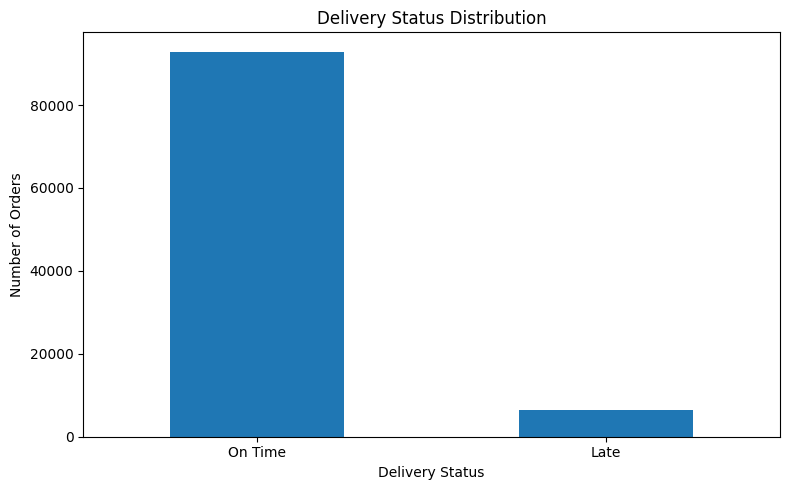

In [93]:
plt.figure(figsize=(8, 5))

ml_data["delivery_status"].value_counts().plot(
    kind="bar"
)

plt.title("Delivery Status Distribution")
plt.xlabel("Delivery Status")
plt.ylabel("Number of Orders")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

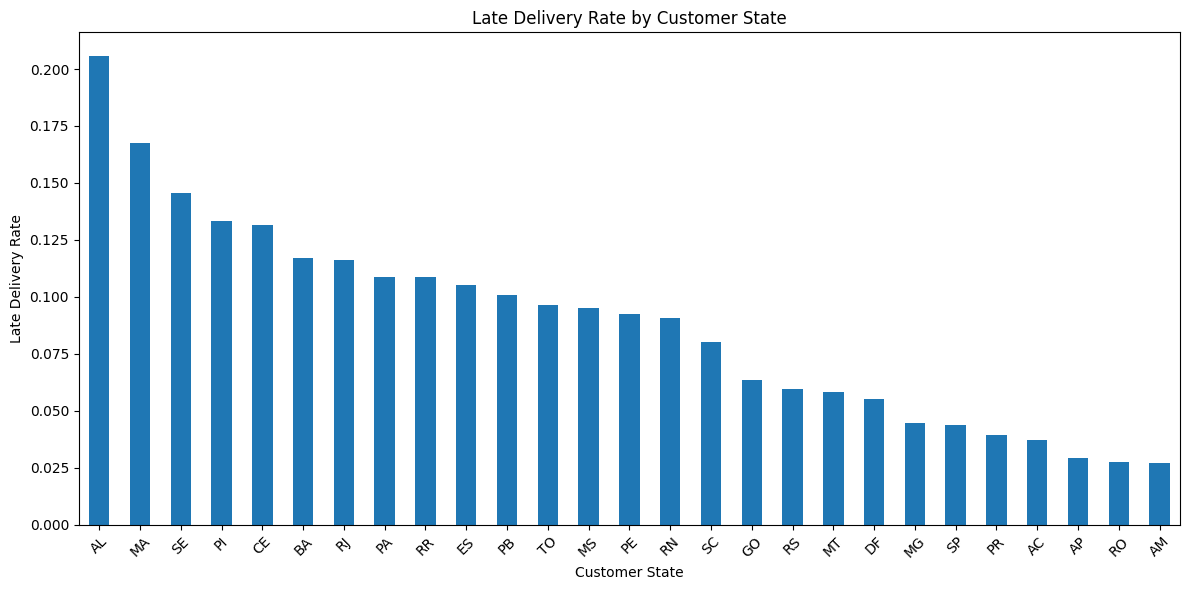

In [94]:
state_late_rate = (
    ml_data.groupby("customer_state")["delivery_status"]
    .apply(lambda x: (x == "Late").mean())
    .sort_values(ascending=False)
)

plt.figure(figsize=(12, 6))

state_late_rate.plot(kind="bar")

plt.title("Late Delivery Rate by Customer State")
plt.xlabel("Customer State")
plt.ylabel("Late Delivery Rate")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

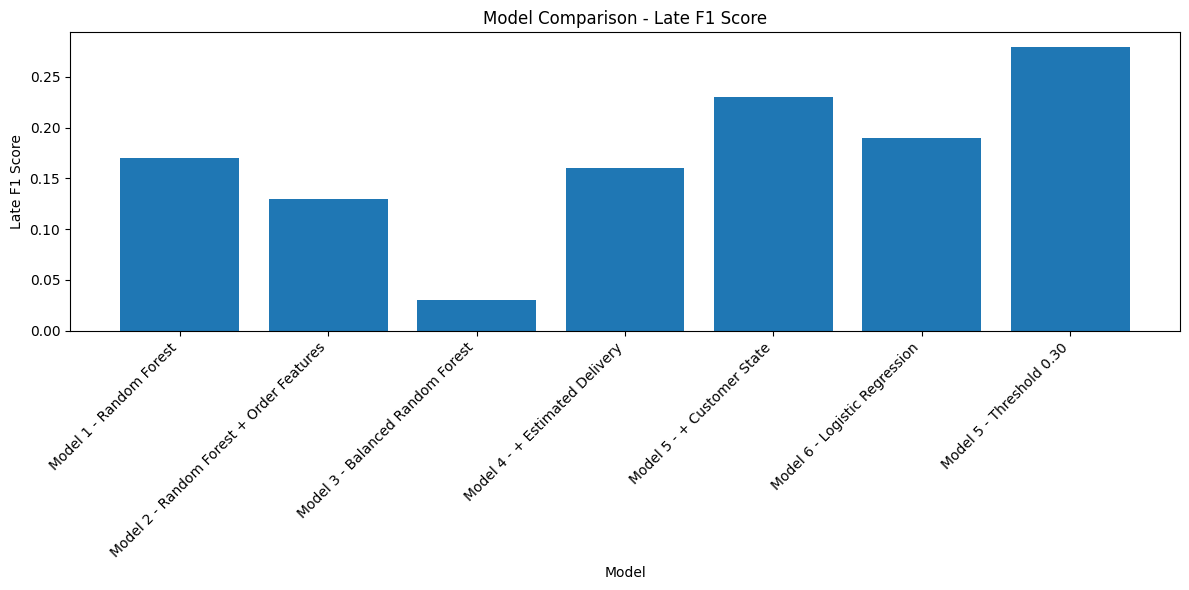

In [95]:
plt.figure(figsize=(12, 6))

plt.bar(
    model_comparison["Model"],
    model_comparison["Late F1"]
)

plt.title("Model Comparison - Late F1 Score")
plt.xlabel("Model")
plt.ylabel("Late F1 Score")

plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

# Key Findings

## 1. Delivery Performance

The dataset contains a significant imbalance between on-time and late deliveries.

- 93.43% of orders were delivered on time.
- 6.57% of orders were delivered late.

This imbalance means that accuracy alone is not an appropriate metric for evaluating the machine-learning models. Precision, recall and F1-score for the Late class were therefore given particular attention.

## 2. Factors Associated with Late Deliveries

The analysis showed differences between late and on-time orders.

Late orders had, on average:

- Higher freight value: 25.25 compared with 22.65 for on-time orders.
- Higher order value: 150.87 compared with 136.82 for on-time orders.
- Slightly shorter estimated delivery periods: 22.29 days compared with 23.48 days.

Item count showed very little difference between late and on-time orders.

## 3. Customer Location

Customer state improved the machine-learning model's ability to identify late deliveries.

After adding `customer_state`, the Random Forest model improved its Late-class performance:

- Late precision increased from 25% to 32%.
- Late recall increased from 12% to 18%.
- Late F1-score increased from 16% to 23%.

This suggests that geographic information contains useful predictive information for delivery performance.

## 4. Model Comparison

Several machine-learning approaches were evaluated.

The model with the highest overall accuracy was the Balanced Random Forest with 93.2% accuracy. However, its Late recall was only 2%, meaning it detected very few genuinely late orders.

Therefore, accuracy alone was not used to select the final model.

The Random Forest model using customer state and a lower classification threshold produced the strongest Late F1-score.

## 5. Final Model

The selected configuration used the Random Forest model with customer state and a classification threshold of 0.30.

Final performance:

- Accuracy: 87.0%
- Late precision: 22%
- Late recall: 40%
- Late F1-score: 28%

Lowering the classification threshold from 0.50 to 0.30 increased Late recall from 18% to 40% and improved the Late F1-score from 23% to 28%.

This demonstrates the trade-off between precision and recall when working with an imbalanced classification problem.

# Business Recommendations

Based on the exploratory analysis and machine-learning results, the following recommendations can be considered.

## 1. Identify High-Risk Deliveries Early

The final model can be used to identify orders with a higher predicted probability of being late.

Orders classified as high risk could receive additional monitoring during the fulfilment and delivery process.

## 2. Use Geographic Information

Customer state improved the model's ability to identify late deliveries.

The business could therefore investigate delivery performance by geographic region and identify states where additional logistics resources or improved delivery partnerships may be required.

## 3. Monitor Freight Costs

Late orders had a higher average freight value than on-time orders.

This suggests that freight-related characteristics may contain useful information about delivery risk. Logistics teams could investigate whether certain shipping methods, routes or delivery services are associated with higher delays.

## 4. Monitor High-Value Orders

Late orders also had a higher average order value.

High-value orders that are predicted to have a higher risk of delay could receive additional monitoring because delays may have a greater impact on customer satisfaction.

## 5. Do Not Rely on Accuracy Alone

The analysis demonstrated that accuracy can be misleading when the target classes are imbalanced.

The dataset contained substantially more on-time orders than late orders. Therefore, precision, recall and F1-score for the Late class should also be considered when evaluating delivery prediction models.

## 6. Use Threshold Tuning

The final analysis showed that lowering the classification threshold from 0.50 to 0.30 increased Late recall from 18% to 40%.

This means the business can adjust the threshold depending on its priorities.

If the priority is to identify as many potentially late orders as possible, a lower threshold may be appropriate. If reducing false alerts is more important, a higher threshold may be preferred.

## Business Impact

The model should be viewed as a decision-support tool rather than a guarantee that an order will be late.

Further testing with additional operational data could potentially improve the model's ability to identify delivery delays.

# Conclusion

This project analysed e-commerce order and delivery data to investigate the factors associated with late deliveries and develop a machine-learning model for predicting delivery delays.

The analysis began with data inspection and cleaning, followed by exploratory data analysis and feature engineering. Several machine-learning models were then developed and evaluated using accuracy, precision, recall and F1-score.

A key challenge was the imbalance between on-time and late deliveries. Although some models achieved accuracy above 90%, they performed poorly when identifying the minority Late class. This demonstrated why accuracy alone is not sufficient for this type of business problem.

The final Random Forest configuration incorporated customer state and used a classification threshold of 0.30. It achieved:

- 87.0% accuracy
- 22% Late precision
- 40% Late recall
- 28% Late F1-score

The threshold adjustment improved the model's ability to identify potentially late deliveries, increasing Late recall from 18% to 40%.

Overall, the project demonstrates a complete data analytics and machine-learning workflow, including data cleaning, exploratory analysis, feature engineering, classification, model evaluation, handling class imbalance and threshold optimisation.

Further improvements could be achieved by incorporating additional operational features such as seller location, product category, shipping method, carrier information and other logistics-related variables, where available.